In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("customer_shopping_clustering.csv")

df

,Purchases_Per_Year,Annual_Spending,Visits_Per_Month,Discount_Usage_Percent,Customer_Type
0,5,618.27,2,81,Budget Shopper
1,5,607.76,2,83,Budget Shopper
2,18,1915.11,6,50,Regular Shopper
3,18,1634.39,4,52,Regular Shopper
4,18,1813.88,6,52,Regular Shopper
...,...,...,...,...,...
235,17,1964.24,5,54,Regular Shopper
236,4,578.36,2,85,Budget Shopper
237,16,1707.24,5,53,Regular Shopper
238,32,4527.05,10,22,Premium Shopper


In [4]:
X = df[["Purchases_Per_Year","Annual_Spending","Visits_Per_Month","Discount_Usage_Percent"]]
X

,Purchases_Per_Year,Annual_Spending,Visits_Per_Month,Discount_Usage_Percent
0,5,618.27,2,81
1,5,607.76,2,83
2,18,1915.11,6,50
3,18,1634.39,4,52
4,18,1813.88,6,52
...,...,...,...,...
235,17,1964.24,5,54
236,4,578.36,2,85
237,16,1707.24,5,53
238,32,4527.05,10,22


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
kmeans = KMeans(n_clusters=4)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [7]:
score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", score*100)

Silhouette Score: 86.05417562265384


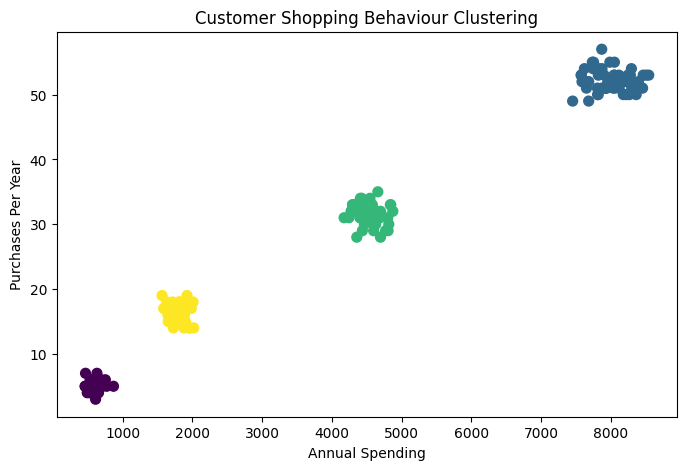

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Annual_Spending"],df["Purchases_Per_Year"],c=df["Cluster"],cmap="viridis",s=50)

plt.xlabel("Annual Spending")
plt.ylabel("Purchases Per Year")
plt.title("Customer Shopping Behaviour Clustering")
plt.show()

In [10]:
purchases = float(input("Enter Purchases Per Year: "))
spending = float(input("Enter Annual Spending: "))
visits = float(input("Enter Visits Per Month: "))
discount = float(input("Enter Discount Usage Percentage: "))

user_data = [[purchases, spending, visits, discount]]

user_scaled = scaler.transform(user_data)

prediction = kmeans.predict(user_scaled)

print("Customer Cluster:", prediction[0])

Enter Purchases Per Year: 18
Enter Annual Spending: 1635.0
Enter Visits Per Month: 2
Enter Discount Usage Percentage: 22
Customer Cluster: 3


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [12]:
df = pd.read_csv("food_delivery_hierarchical_clustering.csv")
df

,Orders_Per_Month,Monthly_Spending,App_Visits_Per_Month,Offers_Used_Percent,Customer_Type
0,16,1765.02,7,26,Regular Order Customer
1,3,441.47,3,11,Low Order Customer
2,48,6734.03,18,70,Frequent Order Customer
3,16,1710.24,5,32,Regular Order Customer
4,31,4274.34,11,54,High Value Customer
...,...,...,...,...,...
235,29,3996.36,9,57,High Value Customer
236,15,1464.62,6,29,Regular Order Customer
237,49,6614.88,17,73,Frequent Order Customer
238,27,3920.45,11,60,High Value Customer


In [13]:
X = df[["Orders_Per_Month","Monthly_Spending","App_Visits_Per_Month","Offers_Used_Percent"]]
X

,Orders_Per_Month,Monthly_Spending,App_Visits_Per_Month,Offers_Used_Percent
0,16,1765.02,7,26
1,3,441.47,3,11
2,48,6734.03,18,70
3,16,1710.24,5,32
4,31,4274.34,11,54
...,...,...,...,...
235,29,3996.36,9,57
236,15,1464.62,6,29
237,49,6614.88,17,73
238,27,3920.45,11,60


In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
model = AgglomerativeClustering(n_clusters=4,)

df["Cluster"] = model.fit_predict(X_scaled)

df

,Orders_Per_Month,Monthly_Spending,App_Visits_Per_Month,Offers_Used_Percent,Customer_Type,Cluster
0,16,1765.02,7,26,Regular Order Customer,3
1,3,441.47,3,11,Low Order Customer,1
2,48,6734.03,18,70,Frequent Order Customer,0
3,16,1710.24,5,32,Regular Order Customer,3
4,31,4274.34,11,54,High Value Customer,2
...,...,...,...,...,...,...
235,29,3996.36,9,57,High Value Customer,2
236,15,1464.62,6,29,Regular Order Customer,3
237,49,6614.88,17,73,Frequent Order Customer,0
238,27,3920.45,11,60,High Value Customer,2


In [16]:
score = silhouette_score(X_scaled,df["Cluster"])

print("Silhouette Score:", score*100)

Silhouette Score: 75.18031309963308


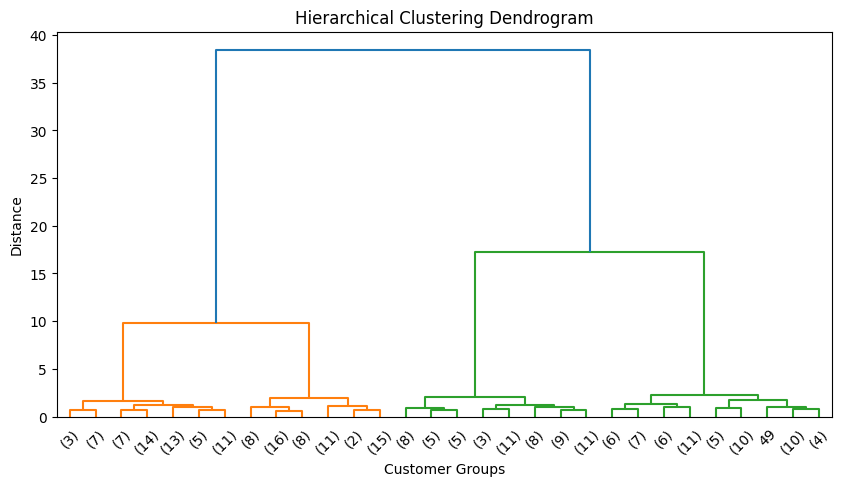

In [17]:
plt.figure(figsize=(10, 5))

linkage_data = linkage(X_scaled,method="ward")

dendrogram(linkage_data,truncate_mode="lastp",p=30)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups")
plt.ylabel("Distance")

plt.show()

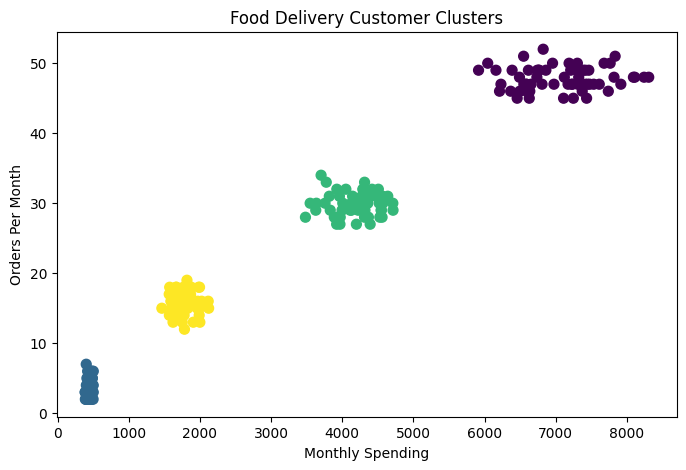

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Monthly_Spending"],df["Orders_Per_Month"],c=df["Cluster"],cmap="viridis",s=50)

plt.xlabel("Monthly Spending")
plt.ylabel("Orders Per Month")
plt.title("Food Delivery Customer Clusters")

plt.show()

In [19]:
orders = float(input("Enter Orders Per Month: "))

spending = float(input("Enter Monthly Spending: "))

visits = float(input("Enter App Visits Per Month: "))

offers = float(input("Enter Offers Used Percentage: "))

user_data = [[orders, spending, visits, offers]]

user_scaled = scaler.transform(user_data)

prediction = model.fit_predict(X_scaled)

user_cluster = model.fit_predict(X_scaled)

print("Customer Cluster:", user_cluster[0])

Enter Orders Per Month: 16
Enter Monthly Spending: 1800
Enter App Visits Per Month: 7
Enter Offers Used Percentage: 11
Customer Cluster: 3


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
%pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2154571 sha256=77e202b9d311df62e4145b278c31f16a7f65a3b8a727f3fe68e0ce1d10b928e6
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

In [23]:
df = pd.read_csv("mobile_app_kmedoids.csv")

df

,Sessions_Per_Week,Minutes_Per_Week,Notifications_Opened,In_App_Purchases,User_Type
0,3,40,1,0,Casual User
1,3,38,3,0,Casual User
2,13,224,12,1,Regular User
3,13,188,14,1,Regular User
4,10,188,14,1,Regular User
...,...,...,...,...,...
235,11,209,15,1,Regular User
236,3,26,4,0,Casual User
237,12,228,16,1,Regular User
238,24,538,37,4,Active User


In [24]:
X = df[["Sessions_Per_Week","Minutes_Per_Week","Notifications_Opened","In_App_Purchases"]]

X

,Sessions_Per_Week,Minutes_Per_Week,Notifications_Opened,In_App_Purchases
0,3,40,1,0
1,3,38,3,0
2,13,224,12,1
3,13,188,14,1
4,10,188,14,1
...,...,...,...,...
235,11,209,15,1
236,3,26,4,0
237,12,228,16,1
238,24,538,37,4


In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
model = KMedoids(n_clusters=4)

df["Cluster"] = model.fit_predict(X_scaled)

df

/usr/local/lib/python3.13/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


,Sessions_Per_Week,Minutes_Per_Week,Notifications_Opened,In_App_Purchases,User_Type,Cluster
0,3,40,1,0,Casual User,1
1,3,38,3,0,Casual User,1
2,13,224,12,1,Regular User,2
3,13,188,14,1,Regular User,2
4,10,188,14,1,Regular User,0
...,...,...,...,...,...,...
235,11,209,15,1,Regular User,0
236,3,26,4,0,Casual User,1
237,12,228,16,1,Regular User,0
238,24,538,37,4,Active User,3


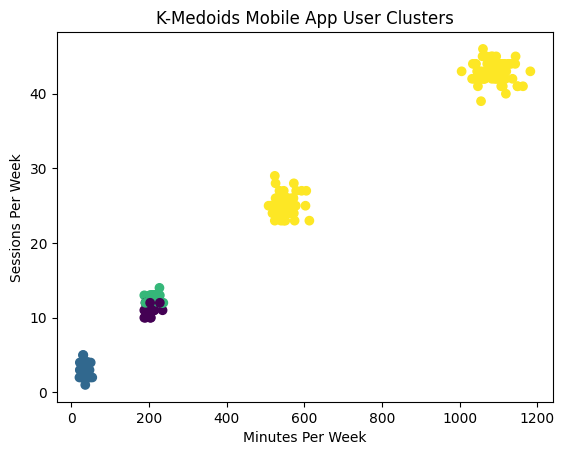

In [29]:
plt.scatter(df["Minutes_Per_Week"],df["Sessions_Per_Week"],c=df["Cluster"],cmap="viridis")

plt.xlabel("Minutes Per Week")
plt.ylabel("Sessions Per Week")
plt.title("K-Medoids Mobile App User Clusters")

plt.show()

In [30]:
sessions = int(input("Enter Sessions Per Week: "))
minutes = int(input("Enter Minutes Per Week: "))
notifications = int(input("Enter Notifications Opened: "))
purchases = int(input("Enter In-App Purchases: "))

user_data = [[sessions, minutes, notifications, purchases]]

user_scaled = scaler.transform(user_data)

prediction = model.predict(user_scaled)

print("User Cluster:", prediction[0])

Enter Sessions Per Week: 25
Enter Minutes Per Week: 550
Enter Notifications Opened: 38
Enter In-App Purchases: 4
User Cluster: 3


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
